# Comparative Analysis of Machine Learning Classifiers on the Iris Dataset

## Experimental Setup


- **Dataset**: Iris Dataset (150 samples, 4 features, 3 classes)
- **Preprocessing**: Standardization applied where required (SVM, MLP)
- **Techniques**: SVM, Random Forest, Decision Tree, Naive Bayes, MLP Classifier with 1, 2, and 3 hidden Layer
- **Evaluation**:
  - K-Fold Cross-Validation (k = 2 to 10)
  - Train–Test Split (80% to 20%)
  - **Metrics**: Mean Accuracy with Standard Deviation, R² Score, Confusion Matrix, Accuracy-Epoch and Loss-Epoch graph.


## Import Libraries


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

## Load the Iris Dataset


In [2]:
iris = load_iris(as_frame=True)
print(iris.data.shape, iris.target.shape)

(150, 4) (150,)


In [3]:
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names
print("Feature names:", feature_names)
print("Class names:", class_names)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']


In [4]:
df = iris.frame
df["species"] = y.apply(lambda x: class_names[x])
df = df.drop(columns=["target"])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Plotting


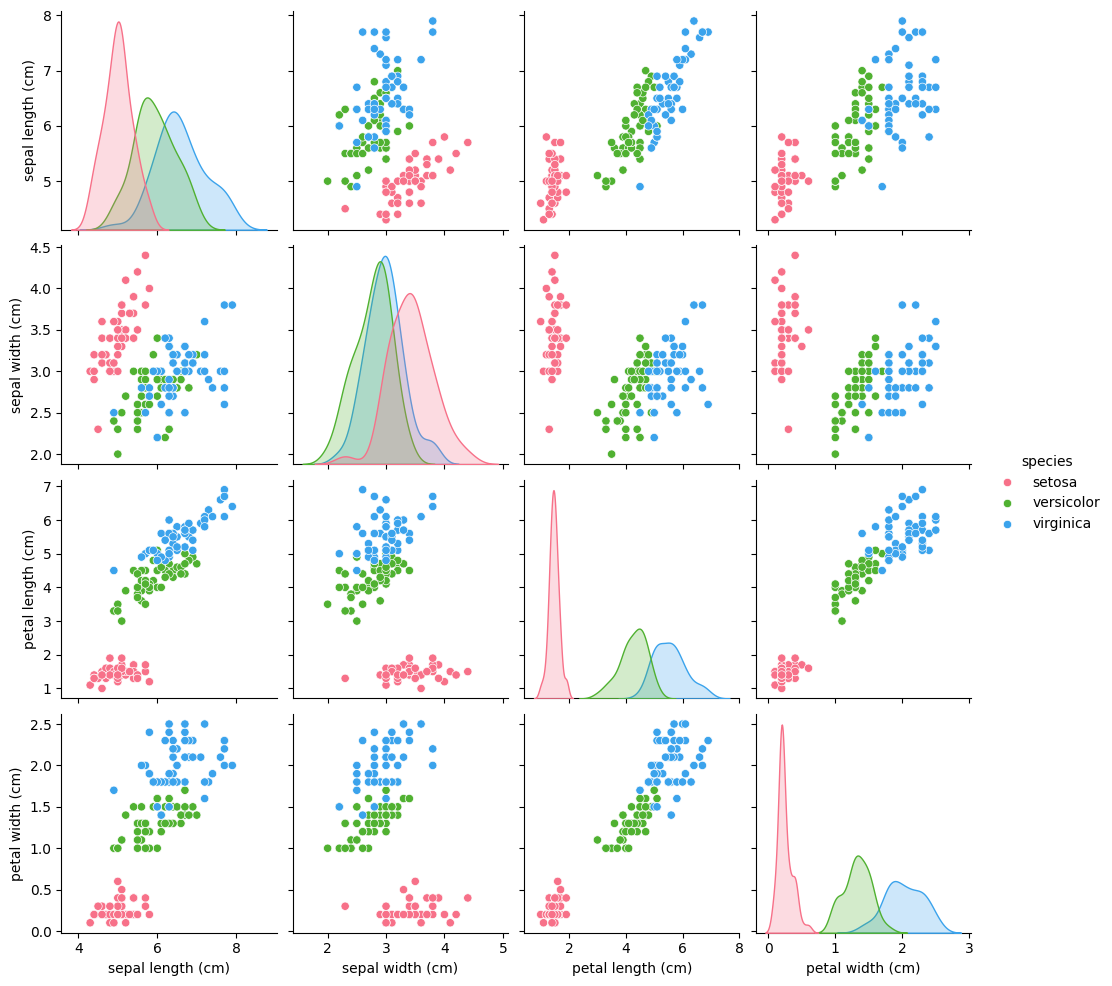

In [5]:
sns.pairplot(df, hue="species", palette="husl")
plt.show()

## Standardizing the features


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Define the Models


In [7]:
models = {
    "SVM": SVC(kernel="linear", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "MLP (1 Hidden Layer)": MLPClassifier(
        hidden_layer_sizes=(8,), max_iter=200, random_state=42
    ),
    "MLP (2 Hidden Layers)": MLPClassifier(
        hidden_layer_sizes=(6, 6), max_iter=200, random_state=42
    ),
    "MLP (3 Hidden Layers)": MLPClassifier(
        hidden_layer_sizes=(4, 4, 4), max_iter=200, random_state=42
    ),
}

## Model Training using K-Fold Cross Validation


In [8]:
k_values = list(range(2, 11))
cv_results = []

for k in k_values:
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    print(f"Performing {k}-fold cross-validation...")

    for name, model in models.items():
        acc_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring="accuracy")
        avg_acc = np.mean(acc_scores)
        std_dev = np.std(acc_scores)

        y_pred = cross_val_predict(model, X_scaled, y, cv=kf)
        r2 = r2_score(y, y_pred)

        cv_results.append(
            {
                "K-Folds": k,
                "Model": name,
                "Mean Accuracy": avg_acc,
                "R² value": r2,
                "Standard Deviations": std_dev,
            }
        )

        print(
            f"Model: {name}, Mean Accuracy: {avg_acc:.4f}, R² value: {r2:.4f}, Standard Deviation: {std_dev:.4f}"
        )

Performing 2-fold cross-validation...
Model: SVM, Mean Accuracy: 0.9800, R² value: 0.9700, Standard Deviation: 0.0067
Model: Random Forest, Mean Accuracy: 0.9600, R² value: 0.9400, Standard Deviation: 0.0000
Model: Decision Tree, Mean Accuracy: 0.9533, R² value: 0.9300, Standard Deviation: 0.0067
Model: Naive Bayes, Mean Accuracy: 0.9533, R² value: 0.9300, Standard Deviation: 0.0067
Model: MLP (1 Hidden Layer), Mean Accuracy: 0.8333, R² value: 0.7500, Standard Deviation: 0.0067
Model: MLP (2 Hidden Layers), Mean Accuracy: 0.8667, R² value: 0.8000, Standard Deviation: 0.0133
Model: MLP (3 Hidden Layers), Mean Accuracy: 0.7600, R² value: 0.5800, Standard Deviation: 0.0667
Performing 3-fold cross-validation...
Model: SVM, Mean Accuracy: 0.9733, R² value: 0.9600, Standard Deviation: 0.0094
Model: Random Forest, Mean Accuracy: 0.9533, R² value: 0.9300, Standard Deviation: 0.0189
Model: Decision Tree, Mean Accuracy: 0.9533, R² value: 0.9300, Standard Deviation: 0.0340
Model: Naive Bayes, Mea

### Comparision Table


In [9]:
df = pd.DataFrame(cv_results)
df["Mean Accuracy"] = df["Mean Accuracy"].astype(float).round(4)
df["R² value"] = df["R² value"].round(4)
df["Standard Deviations"] = df["Standard Deviations"].astype(float).round(4)
df

,K-Folds,Model,Mean Accuracy,R² value,Standard Deviations
0,2,SVM,0.9800,0.97,0.0067
1,2,Random Forest,0.9600,0.94,0.0000
2,2,Decision Tree,0.9533,0.93,0.0067
3,2,Naive Bayes,0.9533,0.93,0.0067
4,2,MLP (1 Hidden Layer),0.8333,0.75,0.0067
...,...,...,...,...,...
58,10,Decision Tree,0.9333,0.90,0.0516
59,10,Naive Bayes,0.9533,0.93,0.0521
60,10,MLP (1 Hidden Layer),0.8400,0.76,0.0800
61,10,MLP (2 Hidden Layers),0.8400,0.76,0.0800


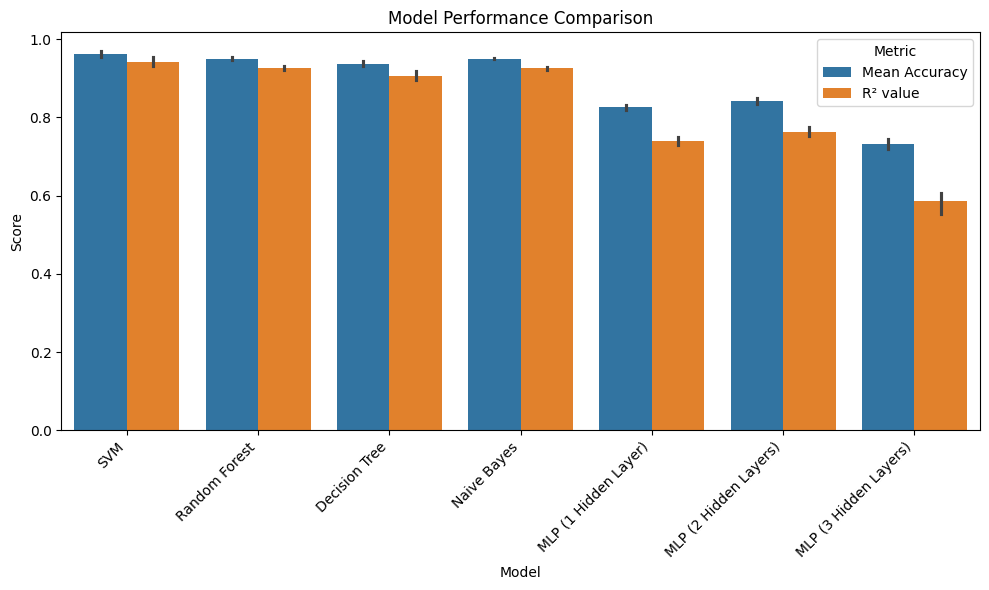

In [10]:
df_long = df.melt(
    id_vars="Model",
    value_vars=["Mean Accuracy", "R² value"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 6))

sns.barplot(data=df_long, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

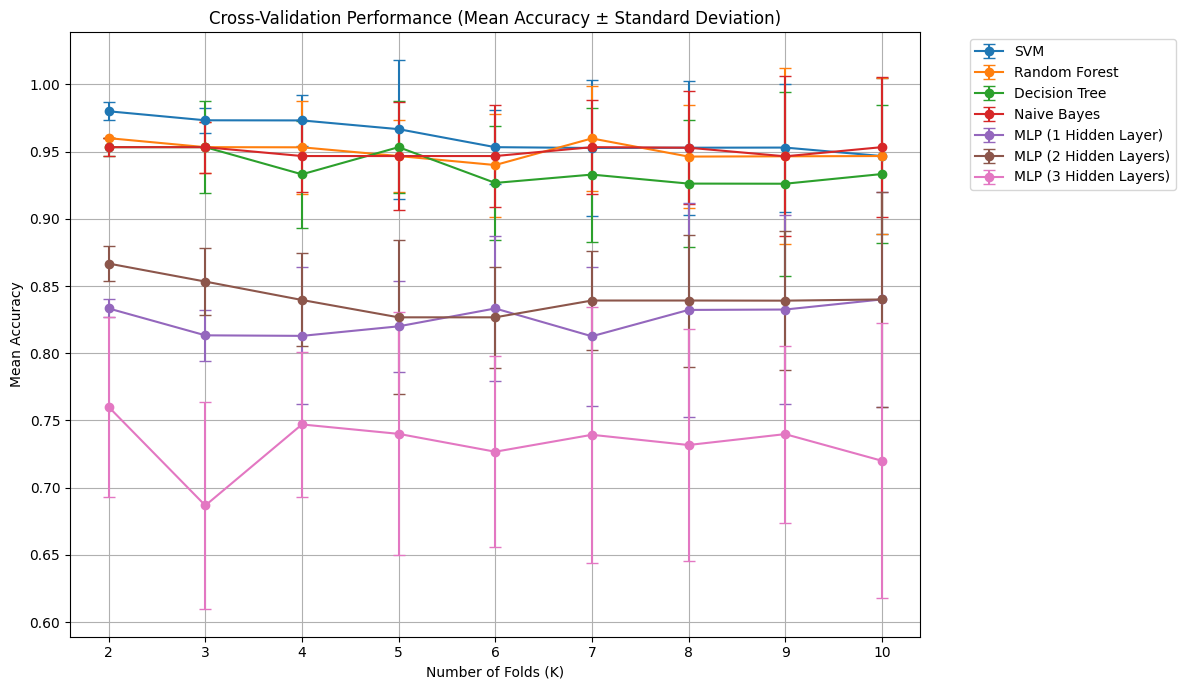

In [11]:
plt.figure(figsize=(12, 7))

for model in models:
    subset = df[df["Model"] == model]
    plt.errorbar(
        subset["K-Folds"],
        subset["Mean Accuracy"],
        yerr=subset["Standard Deviations"],
        marker="o",
        capsize=4,
        label=model,
    )

plt.xlabel("Number of Folds (K)")
plt.ylabel("Mean Accuracy")
plt.title("Cross-Validation Performance (Mean Accuracy ± Standard Deviation)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Mean Accuracy comparison by k-fold


In [12]:
df_acc = df.pivot(index="K-Folds", columns="Model", values="Mean Accuracy")
df_acc = df_acc[df_acc.columns[::-1]]
df_acc

Model,SVM,Random Forest,Naive Bayes,MLP (3 Hidden Layers),MLP (2 Hidden Layers),MLP (1 Hidden Layer),Decision Tree
K-Folds,,,,,,,
2,0.9800,0.9600,0.9533,0.7600,0.8667,0.8333,0.9533
3,0.9733,0.9533,0.9533,0.6867,0.8533,0.8133,0.9533
4,0.9732,0.9532,0.9467,0.7470,0.8396,0.8129,0.9331
5,0.9667,0.9467,0.9467,0.7400,0.8267,0.8200,0.9533
6,0.9533,0.9400,0.9467,0.7267,0.8267,0.8333,0.9267
7,0.9527,0.9598,0.9533,0.7393,0.8392,0.8126,0.9329
8,0.9529,0.9463,0.9529,0.7317,0.8392,0.8322,0.9262
9,0.9530,0.9465,0.9465,0.7398,0.8391,0.8325,0.9261
10,0.9467,0.9467,0.9533,0.7200,0.8400,0.8400,0.9333


#### Standard deviation comparison by k-fold


In [13]:
df_std = df.pivot(index="K-Folds", columns="Model", values="Standard Deviations")
df_std = df_std[df_std.columns[::-1]]
df_std

Model,SVM,Random Forest,Naive Bayes,MLP (3 Hidden Layers),MLP (2 Hidden Layers),MLP (1 Hidden Layer),Decision Tree
K-Folds,,,,,,,
2,0.0067,0.0000,0.0067,0.0667,0.0133,0.0067,0.0067
3,0.0094,0.0189,0.0189,0.0772,0.0249,0.0189,0.0340
4,0.0191,0.0346,0.0267,0.0540,0.0346,0.0510,0.0398
5,0.0516,0.0267,0.0400,0.0904,0.0573,0.0340,0.0340
6,0.0275,0.0383,0.0377,0.0709,0.0377,0.0537,0.0427
7,0.0509,0.0388,0.0352,0.0953,0.0370,0.0516,0.0498
8,0.0498,0.0383,0.0422,0.0864,0.0491,0.0798,0.0471
9,0.0476,0.0656,0.0595,0.0658,0.0519,0.0705,0.0685
10,0.0581,0.0581,0.0521,0.1024,0.0800,0.0800,0.0516


#### R² value comparison by k-fold


In [14]:
df_r2 = df.pivot(index="K-Folds", columns="Model", values="R² value")
df_r2 = df_r2[df_r2.columns[::-1]]
df_r2

Model,SVM,Random Forest,Naive Bayes,MLP (3 Hidden Layers),MLP (2 Hidden Layers),MLP (1 Hidden Layer),Decision Tree
K-Folds,,,,,,,
2,0.97,0.94,0.93,0.58,0.80,0.75,0.93
3,0.96,0.93,0.93,0.47,0.78,0.72,0.93
4,0.96,0.93,0.92,0.62,0.76,0.72,0.90
5,0.95,0.92,0.92,0.61,0.74,0.73,0.93
6,0.93,0.91,0.92,0.59,0.74,0.75,0.89
7,0.93,0.94,0.93,0.61,0.76,0.72,0.90
8,0.93,0.92,0.93,0.60,0.76,0.75,0.89
9,0.93,0.92,0.92,0.61,0.76,0.75,0.89
10,0.92,0.92,0.93,0.58,0.76,0.76,0.90


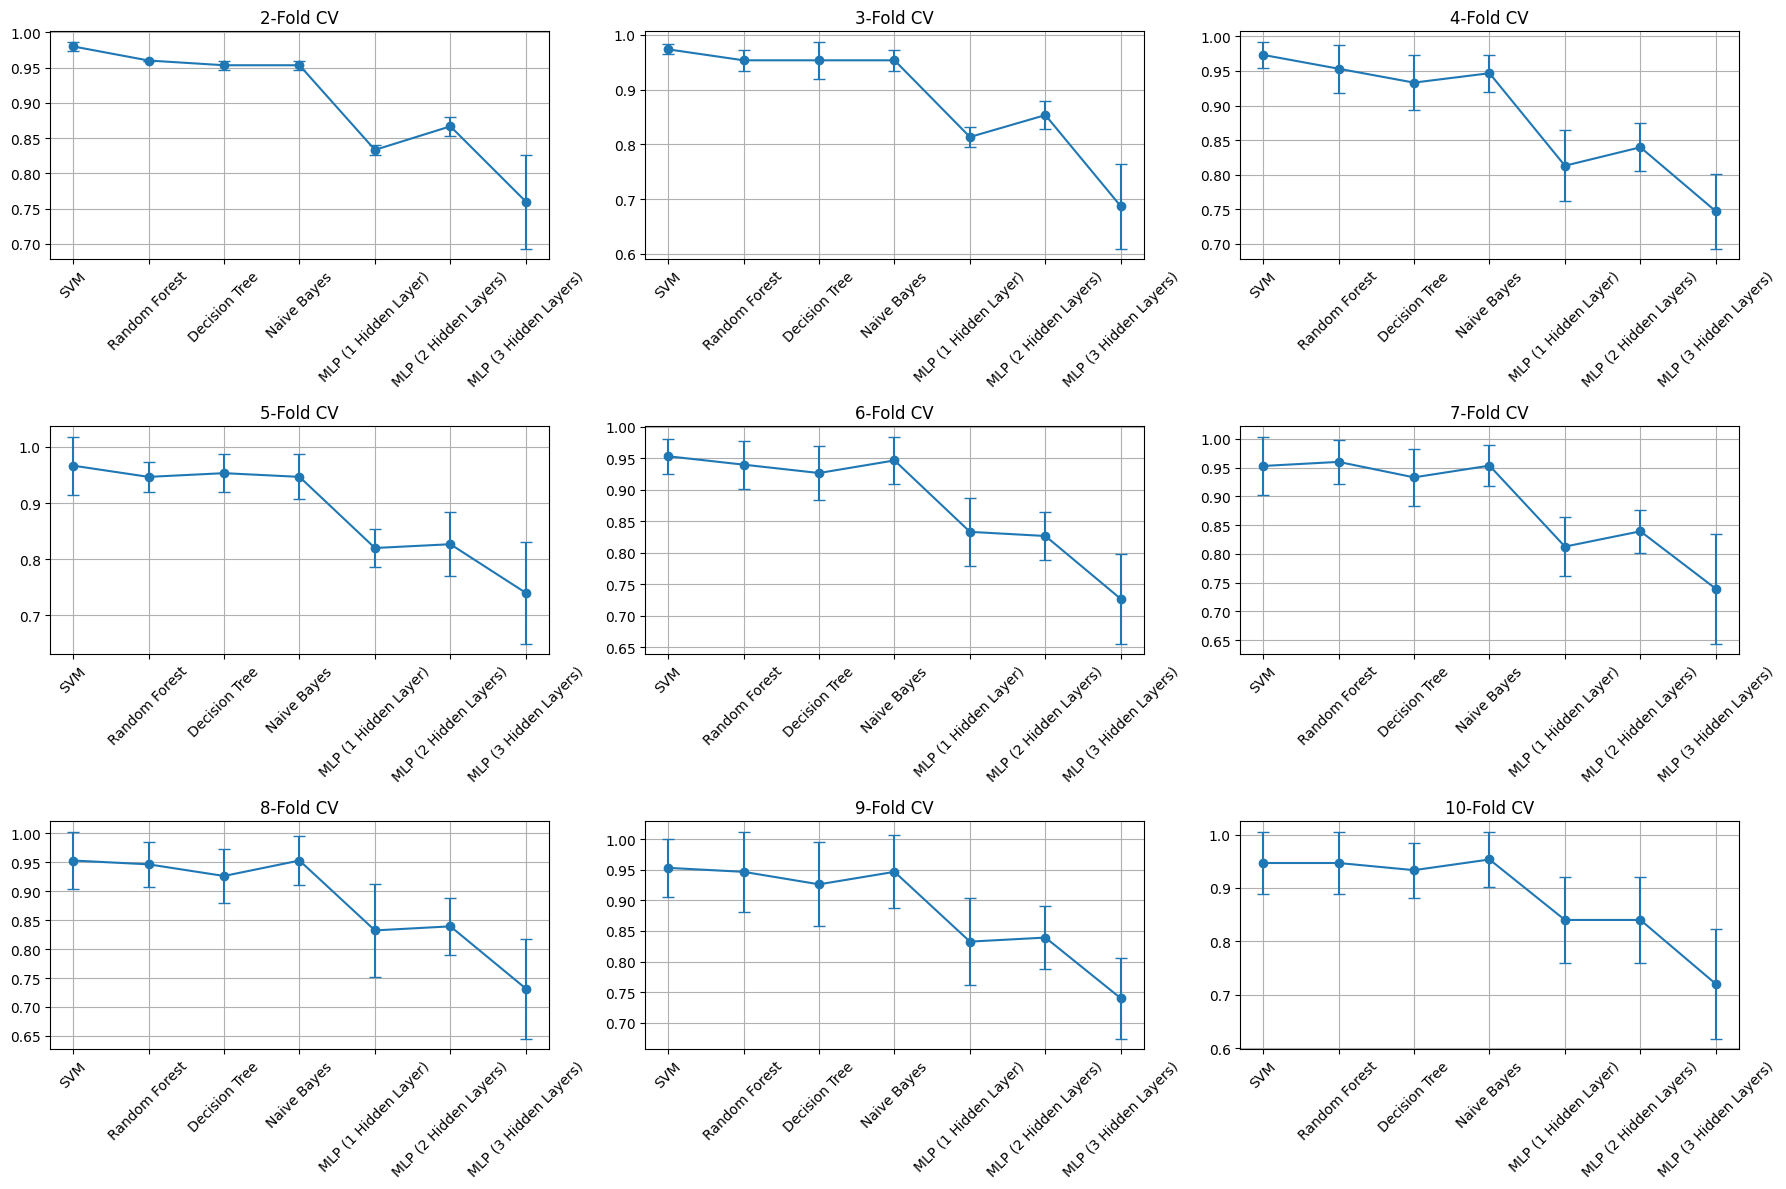

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, i in zip(axes, range(2, 11)):
    df_k = df[df["K-Folds"] == i]
    ax.errorbar(
        df_k["Model"],
        df_k["Mean Accuracy"],
        yerr=df_k["Standard Deviations"],
        fmt="o-",
        capsize=4,
    )
    ax.set_title(f"{i}-Fold CV")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)

plt.tight_layout()
plt.show()

### Confusion Matrix


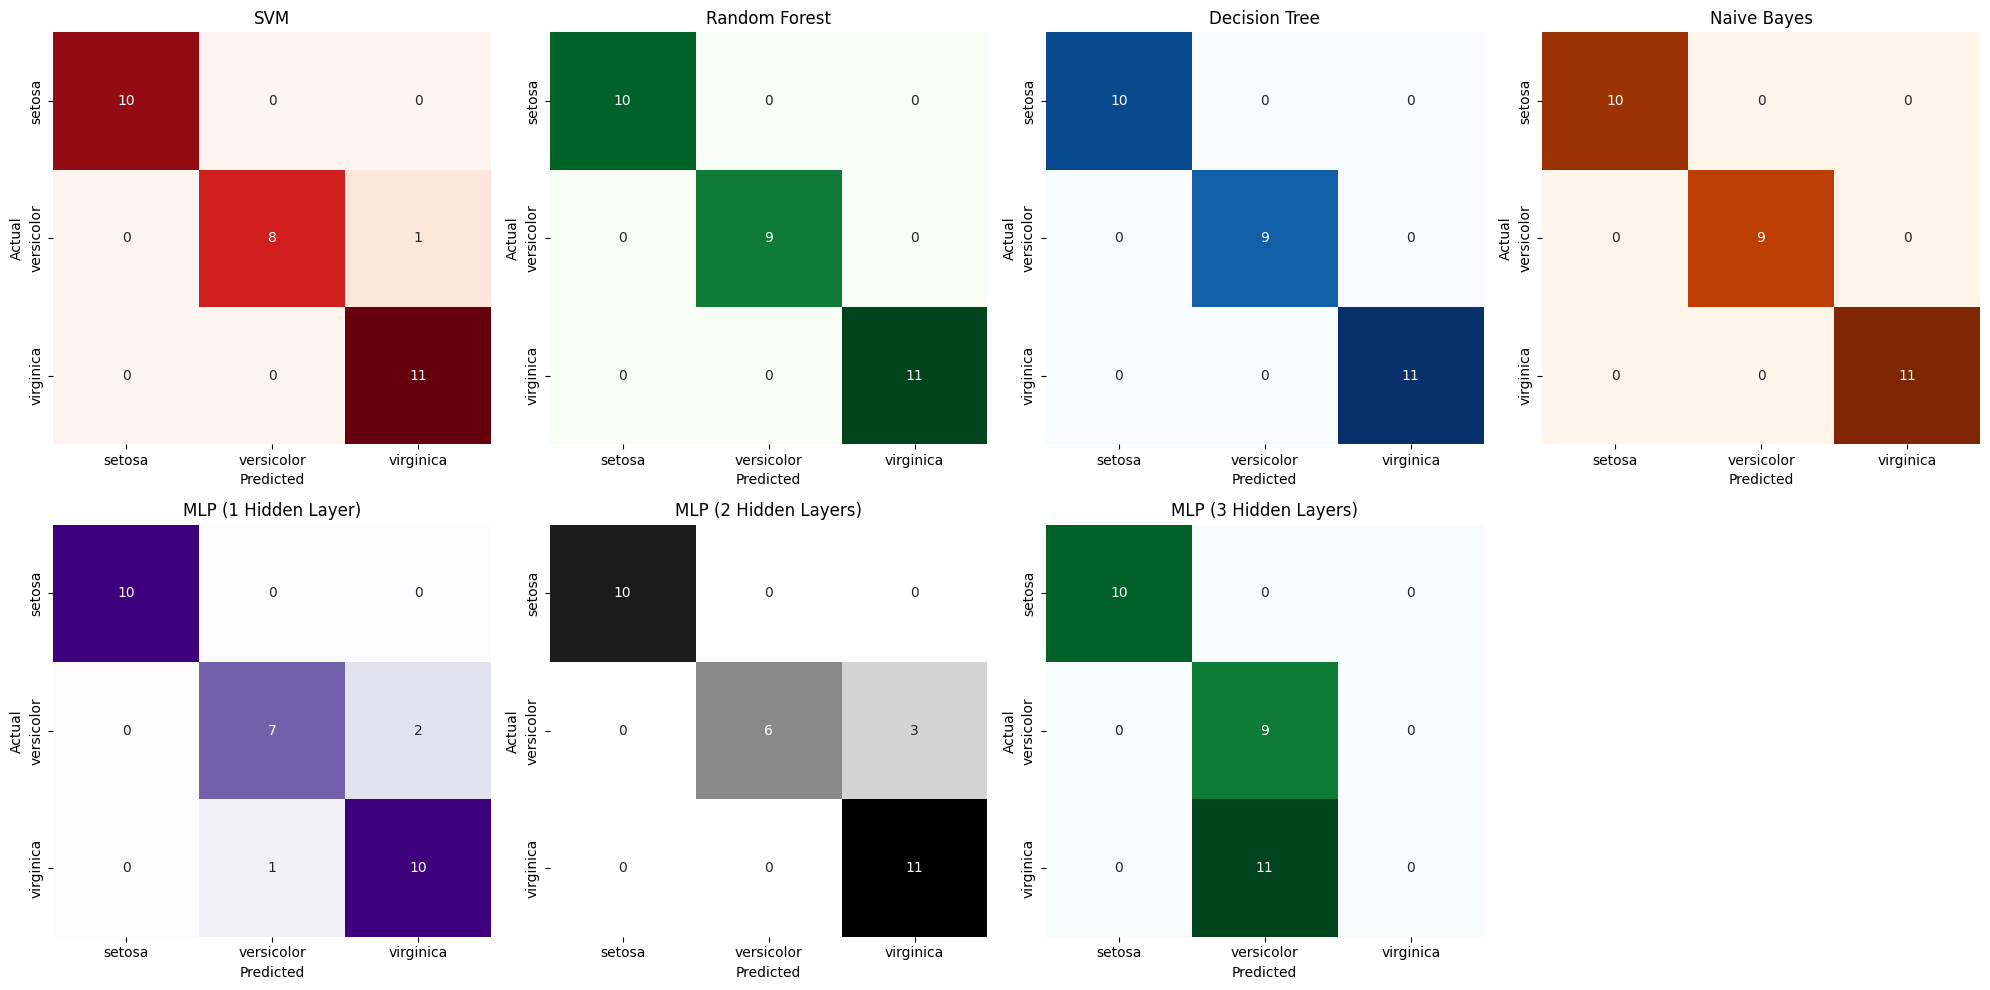

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=True, random_state=42
)

cmap = ["Reds", "Greens", "Blues", "Oranges", "Purples", "Greys", "BuGn"]

plt.figure(figsize=(20, 10))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(2, 4, i + 1)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap[i % len(cmap)],
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Loss vs Epoch & Accuracy vs Epoch Comparison


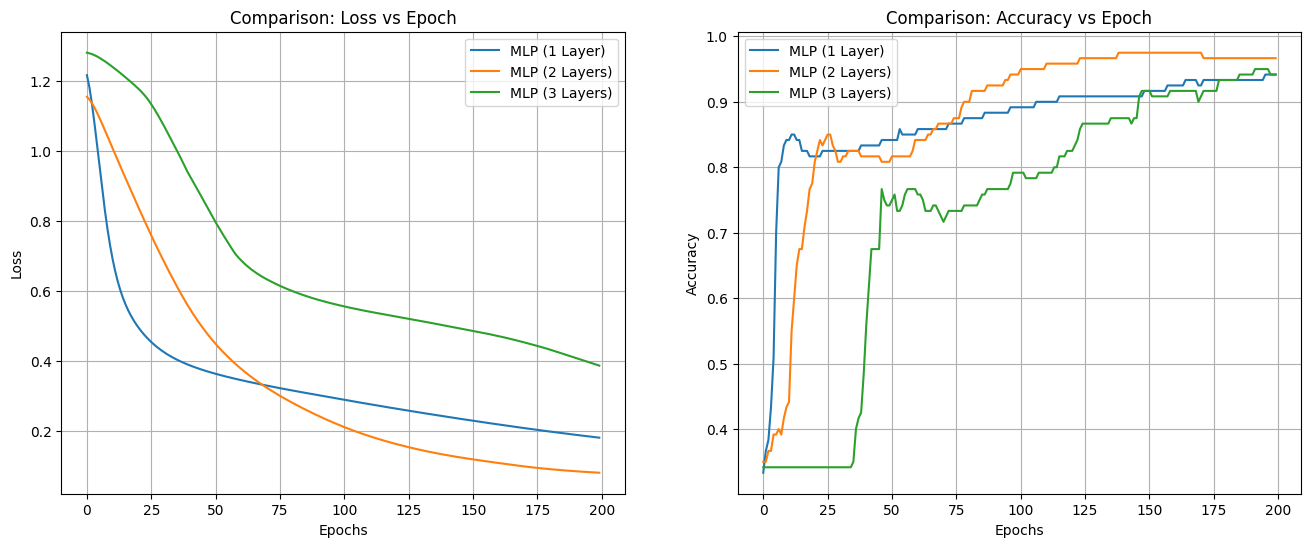

In [17]:
mlp_configs = {
    "MLP (1 Layer)": (8,),
    "MLP (2 Layers)": (6, 6),
    "MLP (3 Layers)": (4, 4, 4),
}

epochs = 200
history = {name: {"loss": [], "accuracy": []} for name in mlp_configs}
classes = np.unique(y)

for name, hidden_layers in mlp_configs.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        max_iter=epochs,
        solver="sgd",
        learning_rate_init=0.01,
        random_state=42,
    )

    for epoch in range(epochs):
        mlp.partial_fit(X_train, y_train, classes=classes)

        history[name]["loss"].append(mlp.loss_)

        pred = mlp.predict(X_train)
        acc = accuracy_score(y_train, pred)
        history[name]["accuracy"].append(acc)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for name in mlp_configs:
    ax[0].plot(history[name]["loss"], label=name)
    ax[1].plot(history[name]["accuracy"], label=name)

ax[0].set_title("Comparison: Loss vs Epoch")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].set_title("Comparison: Accuracy vs Epoch")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.show()

In [18]:
epoch_data = []
for name in mlp_configs:
    for i in range(0, epochs):
        epoch_data.append(
            {
                "Model": name,
                "Epoch": i + 1,
                "Loss": history[name]["loss"][i],
                "Accuracy": history[name]["accuracy"][i],
            }
        )
df_epoch = pd.DataFrame(epoch_data)
df_epoch.pivot(index="Epoch", columns="Model", values=["Loss", "Accuracy"])

Loss                                    Accuracy  \
Model MLP (1 Layer) MLP (2 Layers) MLP (3 Layers) MLP (1 Layer)   
Epoch                                                             
1          1.216851       1.155103       1.281083      0.333333   
2          1.181215       1.147257       1.279376      0.366667   
3          1.132936       1.136459       1.276936      0.383333   
4          1.075721       1.123383       1.273815      0.433333   
5          1.013555       1.108679       1.270126      0.508333   
...             ...            ...            ...           ...   
196        0.183796       0.081797       0.396035      0.941667   
197        0.182916       0.081351       0.393608      0.941667   
198        0.182040       0.080916       0.391190      0.941667   
199        0.181171       0.080492       0.388770      0.941667   
200        0.180306       0.080077       0.386345      0.941667   

                                     
Model MLP (2 Layers) MLP (3 Layers)  
Epoch                                
1           0.350000       0.341667  
2           0.350000       0.341667  
3           0.366667       0.341667  
4           0.366667       0.341667  
5           0.391667       0.341667  
...              ...            ...  
196         0.966667       0.950000  
197         0.966667       0.950000  
198         0.966667       0.941667  
199         0.966667       0.941667  
200         0.966667       0.941667  

[200 rows x 6 columns]

## Overall Comparison Report


In [19]:
summary_rows = []

for model, g in df.groupby("Model"):
    acc_min = g["Mean Accuracy"].min()
    acc_max = g["Mean Accuracy"].max()
    best_acc_row = g.loc[g["Mean Accuracy"].idxmax()]

    r2_min = g["R² value"].min()
    r2_max = g["R² value"].max()
    best_r2_row = g.loc[g["R² value"].idxmax()]

    summary_rows.append(
        {
            "Model Name": model,
            "Accuracy Range": f"{acc_min:.4f} - {acc_max:.4f}",
            "Best Accuracy": round(acc_max, 4),
            "Best Accuracy achieved at K": int(best_acc_row["K-Folds"]),
            "R² Score Range": f"{r2_min:.2f} - {r2_max:.2f}",
            "Best R² Score": round(r2_max, 2),
            "Best R² Score achieved at K": int(best_r2_row["K-Folds"]),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.iloc[::-1].reset_index(drop=True)
summary_df

,Model Name,Accuracy Range,Best Accuracy,Best Accuracy achieved at K,R² Score Range,Best R² Score,Best R² Score achieved at K
0,SVM,0.9467 - 0.9800,0.9800,2,0.92 - 0.97,0.97,2
1,Random Forest,0.9400 - 0.9600,0.9600,2,0.91 - 0.94,0.94,2
2,Naive Bayes,0.9465 - 0.9533,0.9533,2,0.92 - 0.93,0.93,2
3,MLP (3 Hidden Layers),0.6867 - 0.7600,0.7600,2,0.47 - 0.62,0.62,4
4,MLP (2 Hidden Layers),0.8267 - 0.8667,0.8667,2,0.74 - 0.80,0.80,2
5,MLP (1 Hidden Layer),0.8126 - 0.8400,0.8400,10,0.72 - 0.76,0.76,10
6,Decision Tree,0.9261 - 0.9533,0.9533,2,0.89 - 0.93,0.93,2


## Results and Discussion

### Overall Cross-Validation Performance

The comparative evaluation across k-fold values ranging from 2 to 10 demonstrates that classical machine learning models—**Support Vector Machine (SVM)**, **Naive Bayes**, and **Random Forest**—consistently achieve high classification accuracy on the Iris dataset.

Among all models, **SVM with a linear kernel** exhibits the most stable and superior performance, reaching a **maximum mean accuracy of 98.0% at 2-fold cross-validation**, along with a high (R²) score of 0.97. This indicates both strong predictive capability and robustness to data partitioning.

Random Forest classifiers maintain consistently high accuracy (approximately **94.0%–96.0%**) across all k values, reaching a **maximum mean accuracy of 96.0% at 2-fold cross-validation**, benefiting from ensemble averaging, which reduces variance compared to single-tree models. However, its peak performance remains marginally lower than that of SVM.

Naive Bayes also performs competitively, achieving mean accuracies between **94.65% and 95.33%**, particularly excelling at lower fold values (best at **2-fold CV**). This suggests that the conditional independence assumption of Naive Bayes aligns well with the relatively well-separated feature distributions of the Iris dataset.

In contrast, the **Decision Tree** classifier shows slightly lower and more variable performance. While it can achieve accuracies above 95% at optimal folds, its higher variance across splits highlights its sensitivity to training data composition, a known limitation of single-tree models.

### Effect of Model Complexity in MLP Classifiers

The Multilayer Perceptron (MLP) models reveal an important trend regarding model complexity. The **single hidden-layer MLP** achieves moderate accuracy (approximately **81.26%–84.00%**) at **10-fold CV**, while increasing the number of hidden layers does not consistently improve performance. In fact, the **3-hidden-layer MLP** shows poor performance at low fold values (as low as **76.0% accuracy at 2-fold CV**) and higher standard deviations, indicating instability and potential overfitting. But, the **2-hidden-layer MLP** has achieved the highest accuracy of **86.67% at 2-fold CV**.

### Interpretation

So, the classification model from the deceseding order is:

SVM with linear kernel > Random Forest > Naive Bayes > Decision Tree > MLP (2-Hidden Layer) > MLP (1-Hidden Layer) > MLP (3-Hidden Layer)